# Recycle Solved with `fsolve`

Many chemical processes include recycle streams. This means that a variable depends on itself: the stream leaving the separator returns to the mixer and changes the reactor inlet. Material balances are the starting point for this kind of problem {cite:p}`felder2016elementary_principles`.

The system is solved with `fsolve`, a SciPy function based on robust numerical algorithms for nonlinear equations {cite:p}`virtanen2020scipy`.

The simplified balance combines reactor conversion and separation:

$$
F_{A,\mathrm{out}}=(F_{A0}+F_{A,\mathrm{rec}})(1-X), \qquad F_{A,\mathrm{rec}}=rF_{A,\mathrm{out}}
$$

```{admonition} What to modify
:class: dropdown
Change `recycle_fraction`, `V`, or `k`. Recycle improves global conversion of fresh feed, but it also increases the internal flow that equipment must handle.
```


Base-case solution
F_A,out reactor = 85.45 mol/min
F_A,recycle     = 55.54 mol/min
F_A to product  = 29.91 mol/min
Global conversion of fresh A = 70.1 %


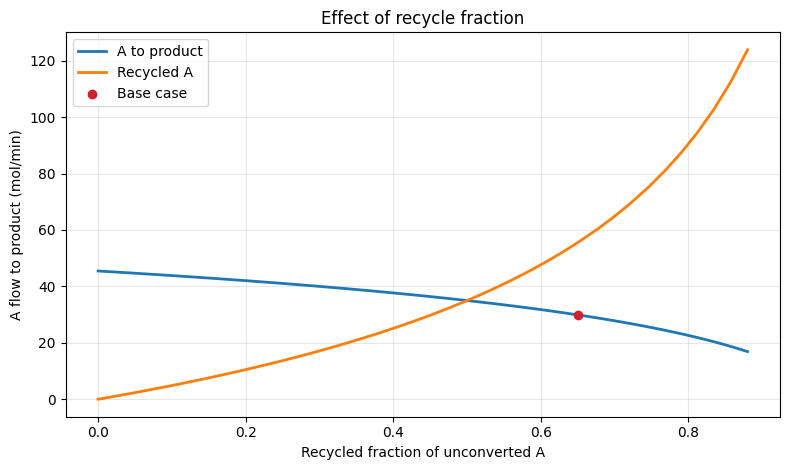

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Editable parameters
F_A0 = 100.0        # fresh molar flow of A (mol/min)
Q0 = 120.0          # fresh volumetric flow (L/min)
C_ref = 1.0         # reference concentration in recycle stream (mol/L)
V = 450.0           # reactor volume (L)
k = 0.32            # first-order kinetic constant (1/min)
recycle_fraction = 0.65


def solve_recycle(recycle_fraction):
    def equations(unknowns):
        F_A_out, F_A_rec = unknowns
        Q_rec = F_A_rec / C_ref
        tau = V / (Q0 + Q_rec)
        X = k * tau / (1 + k * tau)
        eq_reactor = F_A_out - (F_A0 + F_A_rec) * (1 - X)
        eq_separator = F_A_rec - recycle_fraction * F_A_out
        return [eq_reactor, eq_separator]
    F_A_out, F_A_rec = fsolve(equations, [35.0, 20.0])
    F_A_product = F_A_out - F_A_rec
    global_conversion = 1 - F_A_product / F_A0
    return F_A_out, F_A_rec, F_A_product, global_conversion

base = solve_recycle(recycle_fraction)
print("Base-case solution")
print(f"F_A,out reactor = {base[0]:.2f} mol/min")
print(f"F_A,recycle     = {base[1]:.2f} mol/min")
print(f"F_A to product  = {base[2]:.2f} mol/min")
print(f"Global conversion of fresh A = {100*base[3]:.1f} %")

fractions = np.linspace(0, 0.88, 40)
results = np.array([solve_recycle(fr) for fr in fractions])

plt.figure(figsize=(8, 4.8))
plt.plot(fractions, results[:, 2], label="A to product", linewidth=2)
plt.plot(fractions, results[:, 1], label="Recycled A", linewidth=2)
plt.scatter([recycle_fraction], [base[2]], color="#cf222e", zorder=5, label="Base case")
plt.xlabel("Recycled fraction of unconverted A")
plt.ylabel("A flow to product (mol/min)")
plt.title("Effect of recycle fraction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation

Recycle increases overall reactant use, but it also increases the internal flow rate. In a real design, conversion, equipment size, energy cost, and inert accumulation must be balanced.

```{admonition} Guided reading
:class: dropdown
Notice that product flow does not increase indefinitely with recycle fraction. The system gains conversion, but the reactor handles more internal flow and a lower effective space time.
```
